In [1]:
from market_clearing import MarketClearing
from strategic_behavior import MPEC, MPEClinearized
import pandas as pd
import utils
from best_response import BR

d:\Logiciel Centrale Lyon\Anaconda\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Question 2

In [2]:
prod_df = pd.DataFrame({
    'producers': ['P1', 'P2', 'P3', 'P4'],
    'capacities': [40, 90, 50, 60],       
    'minFuelCosts': [10, 30, 35, 55],      
    'maxFuelCosts': [15, 60, 70, 90] 
})

demand = 155

strategic_producer = 'P1'
mc = MarketClearing(bids=prod_df['minFuelCosts'].to_list(), marginal_costs=prod_df['minFuelCosts'].to_list(), demand=demand, prod_df=prod_df)
print(mc.get_price())

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 5 rows, 4 columns and 8 nonzeros
Model fingerprint: 0x9ef673f4
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 2e+02]
Presolve removed 4 rows and 1 columns
Presolve time: 0.05s
Presolved: 1 rows, 3 columns, 3 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.8500000e+03   3.125000e+00   0.000000e+00      0s
       1    3.9750000e+03   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.07 seconds (0.00 work units)
Optimal objective  3.975000000e+03
Pg : Size=4, Index=G
    Key : Lower : Value : Upper : Fixed : Stale : Domain
      0 :   

## Trustful competitors

In [8]:
mpec = MPEClinearized(producer='P1', alphas=prod_df['minFuelCosts'].to_list(), marginal_costs=prod_df['minFuelCosts'].to_list(), prod_df=prod_df, demand=demand, bigM=200, upper_bid=200)
print(mpec.get_profit())
print(mpec.get_results())
profit = mpec.get_profit()

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 31 rows, 25 columns and 65 nonzeros
Model fingerprint: 0xc036227c
Variable types: 14 continuous, 11 integer (11 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 2e+02]
  Bounds range     [1e+00, 2e+02]
  RHS range        [3e+01, 2e+02]
Found heuristic solution: objective -1000.000000
Presolve removed 31 rows and 25 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 1: -1000 
No other solutions better than -1000

Optimal solution found (tolerance 1.00e-04)
Best objective -1.000000000000e+03, best 

RangeIndex(start=0, stop=4, step=1)
0
RangeIndex(start=0, stop=4, step=1)
1
1
RangeIndex(start=0, stop=4, step=1)
2
2
RangeIndex(start=0, stop=4, step=1)
3
3
   production  bids producer  capacities    color   xpos  cumulative_capa
0        40.0  29.0       P1          40  #384E77   20.0               40
1        90.0  30.0       P2          90  #8BBEB2   85.0              130
2        25.0  35.0       P3          50  #E6F9AF  155.0              180
3         0.0  55.0       P4          60     pink  210.0              240
Power plant that sets the electricity price is:  2


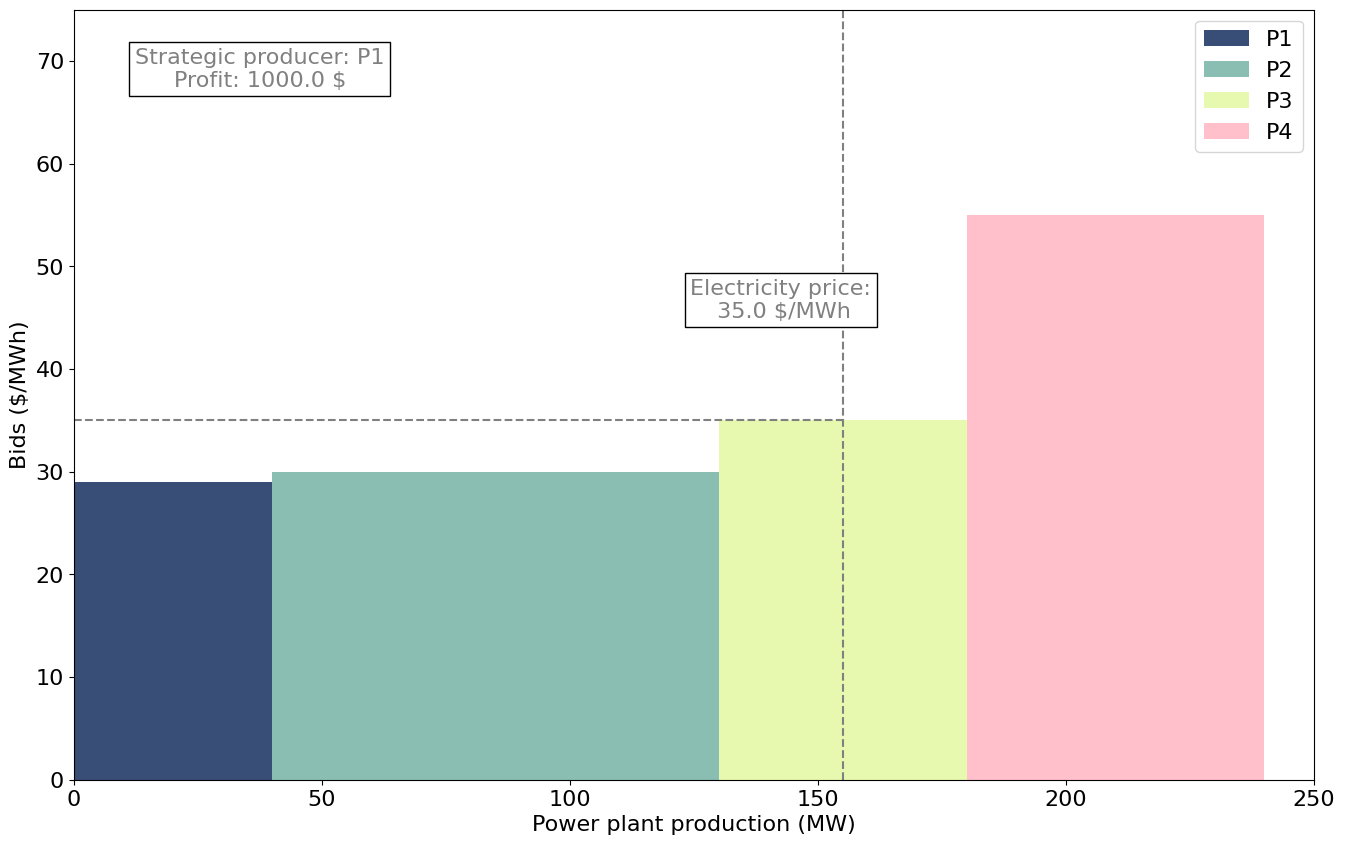

In [9]:
utils.plot_merit_order(mpec.get_results(), demand=demand, strategic_producer=strategic_producer, sp_profit=profit)

## Overbidding competitors

In [6]:
mpec = MPEClinearized(producer='P1', alphas=[10, 40, 45, 120], marginal_costs=prod_df['minFuelCosts'].to_list(), prod_df=prod_df, demand=demand, bigM=200, upper_bid=200)
print(mpec.get_profit())
print(mpec.get_results())
profit = mpec.get_profit()

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 31 rows, 25 columns and 65 nonzeros
Model fingerprint: 0xa6ec9213
Variable types: 14 continuous, 11 integer (11 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+01, 2e+02]
  Bounds range     [1e+00, 2e+02]
  RHS range        [4e+01, 2e+02]
Found heuristic solution: objective -1400.000000
Presolve removed 24 rows and 20 columns
Presolve time: 0.00s
Presolved: 7 rows, 5 columns, 17 nonzeros
Variable types: 3 continuous, 2 integer (2 binary)

Root relaxation: objective -1.635000e+03, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd

Index([1, 2, 0, 3], dtype='int64')
0
Index([1, 2, 0, 3], dtype='int64')
1
2
Index([1, 2, 0, 3], dtype='int64')
2
0
Index([1, 2, 0, 3], dtype='int64')
3
3
   production   bids producer  capacities    color   xpos  cumulative_capa
1        90.0   40.0       P2          90  #8BBEB2   45.0               90
2        50.0   45.0       P3          50  #E6F9AF  115.0              140
0        15.0  119.0       P1          40  #384E77  160.0              180
3         0.0  120.0       P4          60     pink  210.0              240
Power plant that sets the electricity price is:  0


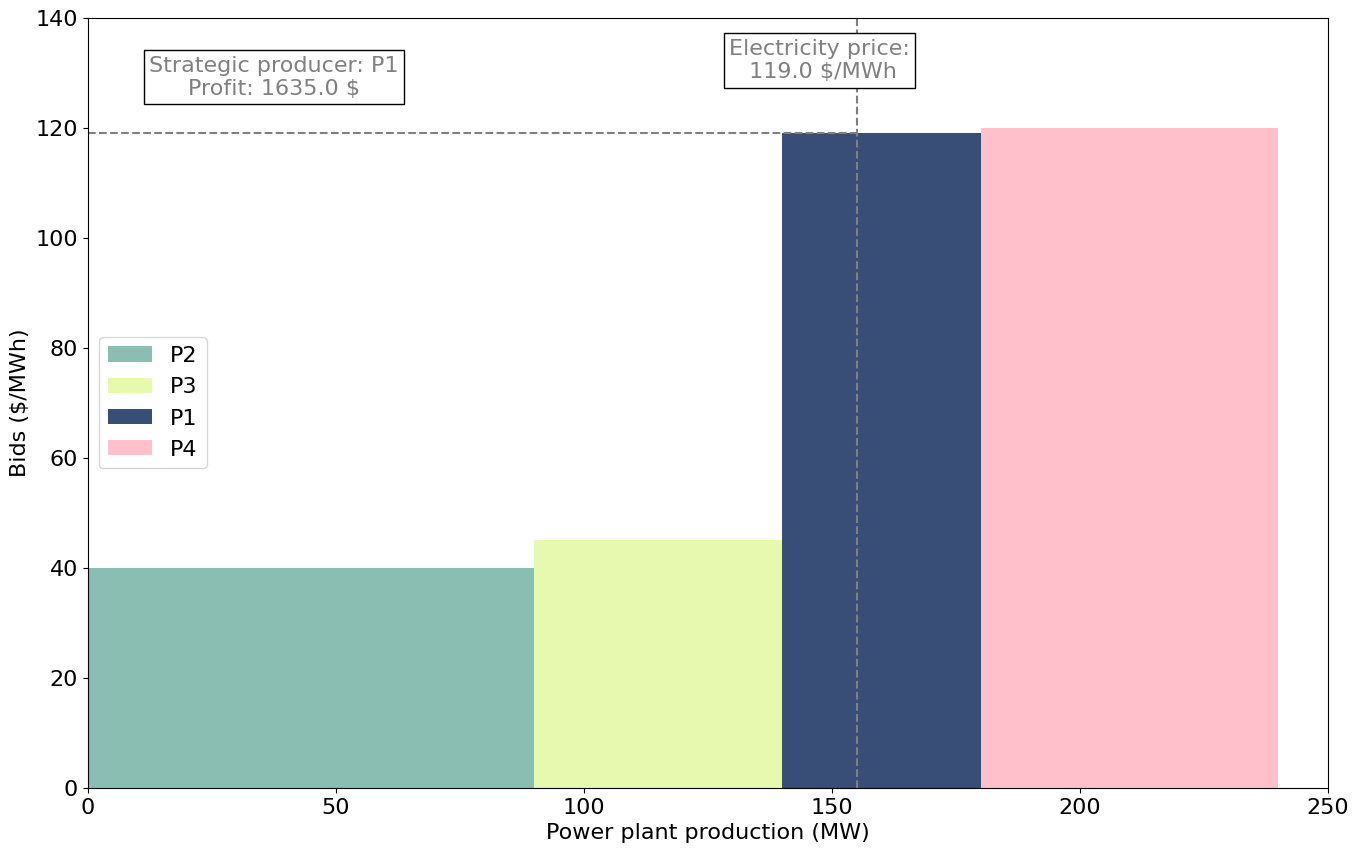

In [7]:
utils.plot_merit_order(mpec.get_results(), demand=demand, strategic_producer=strategic_producer, sp_profit=profit)